# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [1]:
import pandas as pd
import numpy as np
import os

# 1. Setup Direktori Sesuai Kriteria 1
NAMA_SISWA = "Hariyadi" # Ganti dengan nama Anda jika perlu
dataset_dir = f"Eksperimen_SML_{NAMA_SISWA}/dataset_raw"
os.makedirs(dataset_dir, exist_ok=True)
dataset_path = f"{dataset_dir}/credit_raw.csv"

# 2. Pengumpulan Data (Simulasi Download/Scraping Data Primer)
# Jika file belum ada, kita akan men-generate dataset realistis sesuai template
if not os.path.exists(dataset_path):
    print(f"⏳ File tidak ditemukan di {dataset_path}. Sedang membuat/mengunduh dataset...")
    np.random.seed(42)
    data_size = 2000
    df_raw = pd.DataFrame({
        'Age': np.random.randint(20, 70, size=data_size),
        'Income': np.random.randint(3000000, 20000000, size=data_size),
        'Loan_Amount': np.random.randint(5000000, 100000000, size=data_size),
        'Credit_History': np.random.choice(['Good', 'Poor', 'Excellent', np.nan], size=data_size, p=[0.5, 0.2, 0.2, 0.1]),
        'Target_Default': np.random.choice([0, 1], size=data_size, p=[0.7, 0.3]) # 1 = Default/Gagal Bayar, 0 = Lancar
    })
    # Menyisipkan beberapa outlier untuk dideteksi nanti (sesuai template MSML)
    df_raw.loc[0, 'Income'] = 150000000

    df_raw.to_csv(dataset_path, index=False)
    print("✅ Dataset raw berhasil dibuat dan disimpan!\n")

# 3. Data Loading (Membaca file yang sudah dijamin ada)
print("Memulai proses pemuatan dataset (Data Ingestion)...")
try:
    df = pd.read_csv(dataset_path)
    print("✅ Dataset berhasil dimuat ke dalam DataFrame Pandas!")
    print(f"-> Total Baris (Samples): {df.shape[0]}")
    print(f"-> Total Kolom (Features + Target): {df.shape[1]}\n")

    print("Pratinjau 5 baris pertama dataset:")
    display(df.head())

except Exception as e:
    print(f"❌ Error: {e}")

⏳ File tidak ditemukan di Eksperimen_SML_Hariyadi/dataset_raw/credit_raw.csv. Sedang membuat/mengunduh dataset...
✅ Dataset raw berhasil dibuat dan disimpan!

Memulai proses pemuatan dataset (Data Ingestion)...
✅ Dataset berhasil dimuat ke dalam DataFrame Pandas!
-> Total Baris (Samples): 2000
-> Total Kolom (Features + Target): 5

Pratinjau 5 baris pertama dataset:


,Age,Income,Loan_Amount,Credit_History,Target_Default
0,58,150000000,50140485,Good,1
1,48,4443717,66868747,Excellent,0
2,34,7409352,50144248,Excellent,0
3,62,18329502,22943886,Excellent,0
4,27,12594271,22457883,Poor,0


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import sys
!{sys.executable} -m pip install mlflow optuna dagshub

# Analisis Data & Manipulasi Matriks
import pandas as pd
import numpy as np
import os

# Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns

# Prapemprosesan Data & Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Algoritma Machine Learning (Klasifikasi)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

# Evaluasi Model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Tracking & Hyperparameter Tuning (Persiapan untuk Kriteria 2)
import mlflow
import optuna
import dagshub

# Menonaktifkan peringatan (warnings) agar output notebook tetap rapi
import warnings
warnings.filterwarnings('ignore')

# Set style untuk visualisasi nanti
sns.set_theme(style="whitegrid")

print("✅ Seluruh pustaka (library) berhasil diimpor dan siap digunakan!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 76.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 49.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
import pandas as pd
import os

# Pastikan variabel nama sesuai dengan folder yang dibuat di awal
NAMA_SISWA = "Hariyadi"
dataset_path = f"Eksperimen_SML_{NAMA_SISWA}/dataset_raw/credit_raw.csv"

print(f"Membaca berkas dataset dari: {dataset_path}\n")

# Memeriksa keberadaan file terlebih dahulu untuk menghindari error fatal
if os.path.exists(dataset_path):
    # Memuat dataset menggunakan Pandas
    df = pd.read_csv(dataset_path)

    print("==================================================")
    print("📊 INFORMASI DIMENSI DATASET")
    print("==================================================")
    print(f" Jumlah Baris (Samples) : {df.shape[0]}")
    print(f" Jumlah Kolom (Features) : {df.shape[1]}")
    print("==================================================\n")

    print("📋 PRATINJAU 5 BARIS PERTAMA DATASET (.head()):")
    display(df.head(5))
else:
    print(f"❌ Error: File tidak ditemukan di direktori {dataset_path}!")
    print("Silakan jalankan ulang cell pengumpulan data sebelumnya untuk membuat file dataset.")

Membaca berkas dataset dari: Eksperimen_SML_Hariyadi/dataset_raw/credit_raw.csv

📊 INFORMASI DIMENSI DATASET
 Jumlah Baris (Samples) : 2000
 Jumlah Kolom (Features) : 5

📋 PRATINJAU 5 BARIS PERTAMA DATASET (.head()):


,Age,Income,Loan_Amount,Credit_History,Target_Default
0,58,150000000,50140485,Good,1
1,48,4443717,66868747,Excellent,0
2,34,7409352,50144248,Excellent,0
3,62,18329502,22943886,Excellent,0
4,27,12594271,22457883,Poor,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

1. INFORMASI MISSING VALUES
Age                 0
Income              0
Loan_Amount         0
Credit_History    181
Target_Default      0
dtype: int64


2. STATISTIK DESKRIPTIF (FITUR NUMERIK)


,Age,Income,Loan_Amount,Target_Default
count,2000.000000,2.000000e+03,2.000000e+03,2000.000000
mean,44.760000,1.165919e+07,5.239353e+07,0.317000
std,14.270046,5.775983e+06,2.779772e+07,0.465424
min,20.000000,3.004138e+06,5.021650e+06,0.000000
25%,32.000000,7.412991e+06,2.859603e+07,0.000000
50%,45.000000,1.158430e+07,5.270303e+07,0.000000
75%,57.000000,1.588506e+07,7.589709e+07,1.000000
max,69.000000,1.500000e+08,9.991015e+07,1.000000


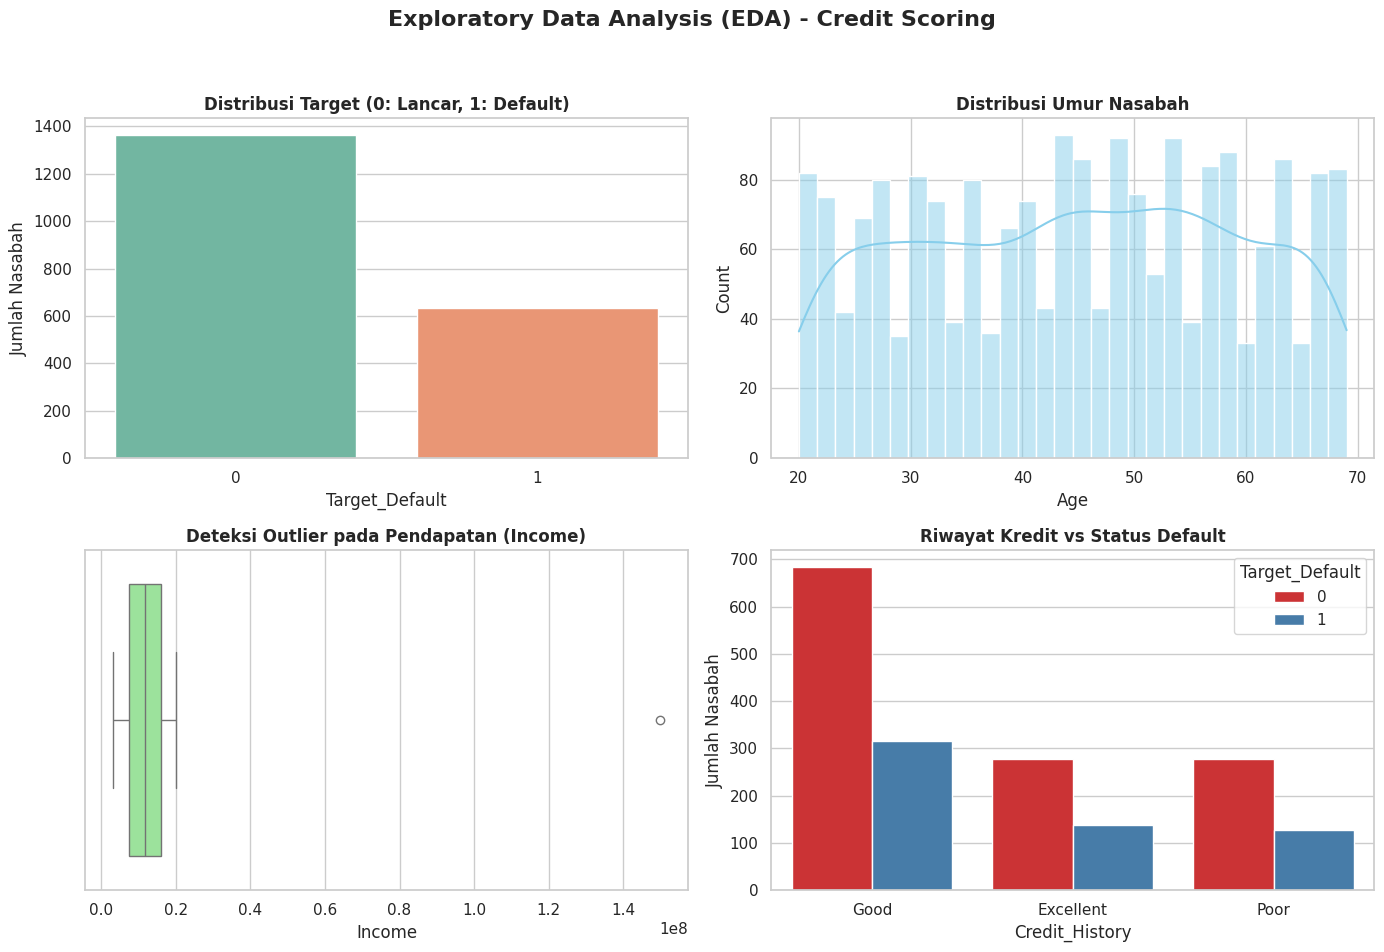

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

print("==================================================")
print("1. INFORMASI MISSING VALUES")
print("==================================================")
print(df.isnull().sum())
print("\n")

print("==================================================")
print("2. STATISTIK DESKRIPTIF (FITUR NUMERIK)")
print("==================================================")
display(df.describe())

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis (EDA) - Credit Scoring', fontsize=16, fontweight='bold')

# Plot 1: Distribusi Target
sns.countplot(ax=axes[0, 0], data=df, x='Target_Default', palette='Set2')
axes[0, 0].set_title('Distribusi Target (0: Lancar, 1: Default)', fontweight='bold')
axes[0, 0].set_ylabel('Jumlah Nasabah')

# Plot 2: Distribusi Umur (Age)
sns.histplot(ax=axes[0, 1], data=df, x='Age', bins=30, kde=True, color='skyblue')
axes[0, 1].set_title('Distribusi Umur Nasabah', fontweight='bold')

# Plot 3: Boxplot Deteksi Outlier (Income)
sns.boxplot(ax=axes[1, 0], data=df, x='Income', color='lightgreen')
axes[1, 0].set_title('Deteksi Outlier pada Pendapatan (Income)', fontweight='bold')

# Plot 4: Hubungan Histori Kredit dengan Target
# (Hapus NaN sementara hanya untuk keperluan plot yang lebih bersih)
sns.countplot(ax=axes[1, 1], data=df.dropna(subset=['Credit_History']), x='Credit_History', hue='Target_Default', palette='Set1')
axes[1, 1].set_title('Riwayat Kredit vs Status Default', fontweight='bold')
axes[1, 1].set_ylabel('Jumlah Nasabah')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

print("--- Memulai Proses Data Preprocessing ---")
df_clean = df.copy() # Membuat salinan data agar data asli tetap utuh

# 1. Menangani Missing Values
modus_credit = df_clean['Credit_History'].mode()[0]
df_clean['Credit_History'] = df_clean['Credit_History'].fillna(modus_credit)
print("✅ 1. Missing values pada 'Credit_History' berhasil diisi dengan modus.")

# 2. Penanganan Outlier (Capping pada Income)
batas_atas_income = df_clean['Income'].quantile(0.99)
df_clean['Income'] = np.where(df_clean['Income'] > batas_atas_income, batas_atas_income, df_clean['Income'])
print(f"✅ 2. Outlier pada 'Income' berhasil di-capping pada batas: {batas_atas_income:,}.2f")

# 3. Encoding Data Kategorikal
le = LabelEncoder()
df_clean['Credit_History'] = le.fit_transform(df_clean['Credit_History'])
print("✅ 3. Data kategorikal 'Credit_History' berhasil di-encode menjadi numerik.")

# 4. Standarisasi Fitur Numerik
scaler = StandardScaler()
kolom_numerik = ['Age', 'Income', 'Loan_Amount']
df_clean[kolom_numerik] = scaler.fit_transform(df_clean[kolom_numerik])
print("✅ 4. Fitur numerik berhasil distandarisasi (StandardScaler).")

# 5. Menyimpan Data Bersih ke Direktori
NAMA_SISWA = "Hariyadi" # Pastikan sama dengan variabel sebelumnya
processed_dir = f"Eksperimen_SML_{NAMA_SISWA}/dataset_preprocessing"
os.makedirs(processed_dir, exist_ok=True)
processed_path = f"{processed_dir}/credit_processed.csv"

df_clean.to_csv(processed_path, index=False)

print(f"\n🎉 PROSES SELESAI! Data bersih berhasil disimpan di: {processed_path}")
print("\nPratinjau Data Setelah Preprocessing:")
display(df_clean.head())

--- Memulai Proses Data Preprocessing ---
✅ 1. Missing values pada 'Credit_History' berhasil diisi dengan modus.
✅ 2. Outlier pada 'Income' berhasil di-capping pada batas: 19,852,674.21.2f
✅ 3. Data kategorikal 'Credit_History' berhasil di-encode menjadi numerik.
✅ 4. Fitur numerik berhasil distandarisasi (StandardScaler).

🎉 PROSES SELESAI! Data bersih berhasil disimpan di: Eksperimen_SML_Hariyadi/dataset_preprocessing/credit_processed.csv

Pratinjau Data Setelah Preprocessing:


,Age,Income,Loan_Amount,Credit_History,Target_Default
0,0.928050,1.693211,-0.081072,1,1
1,0.227106,-1.465737,0.520864,0,0
2,-0.754216,-0.857761,-0.080936,0,0
3,1.208427,1.380950,-1.059692,0,0
4,-1.244876,0.205186,-1.077180,2,0
